epoch=0, loss=105.7228, w=0.2150, b=0.1995
epoch=200, loss=1.1733, w=4.6687, b=5.4308
epoch=400, loss=1.0422, w=4.3365, b=5.8074
epoch=600, loss=1.0062, w=4.1616, b=6.0045
epoch=800, loss=0.9962, w=4.0698, b=6.1079
최종 w: 4.021813642697164
최종 b: 6.162031224717461


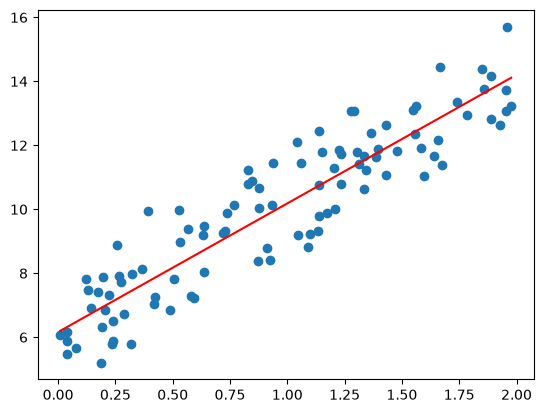

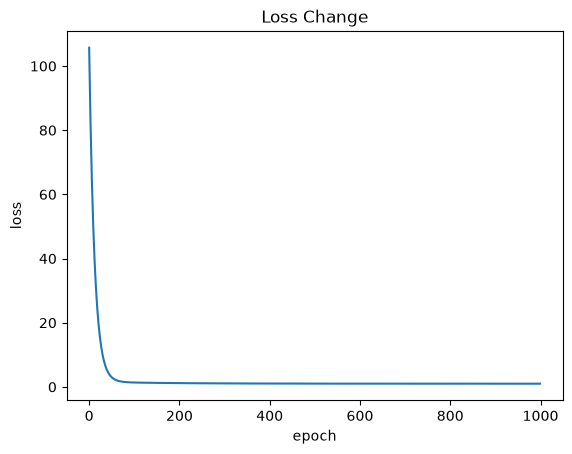

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 6 + 4 * X + np.random.randn(100, 1)

# 2. 초기값 설정
w = 0
b = 0
learning_rate = 0.01
epochs = 1000
n = len(X)

loss_history = []

# 3. 경사하강법 반복
for epoch in range(epochs):
    # 예측값
    y_pred = w * X + b

    # 오차
    error = y_pred - y

    # 손실값(MSE)
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # 기울기 계산
    w_grad = (2 / n) * np.sum(X * error)
    b_grad = (2 / n) * np.sum(error)

    # 파라미터 업데이트
    w = w - learning_rate * w_grad
    b = b - learning_rate * b_grad

    # 중간 결과 확인
    if epoch % 200 == 0:
        print(f"epoch={epoch}, loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

print("최종 w:", w)
print("최종 b:", b)

# 4. 학습된 직선 시각화
X_sorted = np.sort(X, axis=0)
y_pred_sorted = w * X_sorted + b

plt.scatter(X, y)
plt.plot(X_sorted, y_pred_sorted, color="red")
plt.show()

# 5. 손실값 변화 시각화
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss Change")
plt.show()

기울기(coefficient): 2.0
절편(intercept): -0.20000000000000018
MSE: 0.15999999999999992
R^2 Score: 0.9803921568627451


c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.c

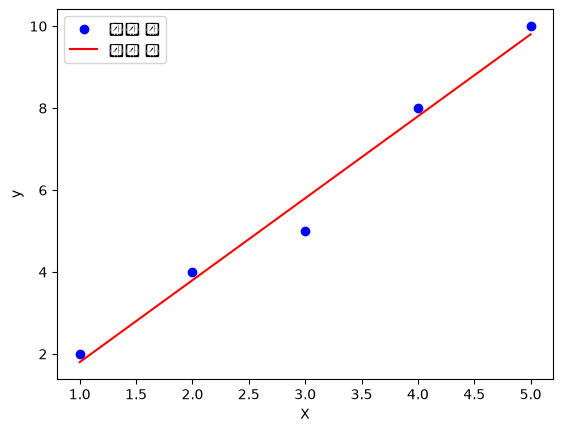

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 생성
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 8, 10])

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 예측 값 계산
y_pred = model.predict(X)

# 평가 지표 계산
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'기울기(coefficient): {model.coef_[0]}')
print(f'절편(intercept): {model.intercept_}')
print(f'MSE: {mse}')
print(f'R^2 Score: {r2}')

# 결과 시각화
plt.scatter(X, y, color='blue', label='실제 값')
plt.plot(X, y_pred, color='red', label='예측 값')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 데이터 생성
X = np.array([[1, 2100], [2, 2500], [3, 1800], [4, 2200], [5, 1700]])
y = np.array([500, 550, 480, 530, 475])

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 예측 값 계산
y_pred = model.predict(X)

# 평가 지표 계산
mse = mean_squared_error(y, y_pred)

print(f'회귀 계수(coefficient): {model.coef_}')
print(f'절편(intercept): {model.intercept_}')
print(f'MSE: {mse}')

회귀 계수(coefficient): [5.36082474 0.11237113]
절편(intercept): 259.4329896907218
MSE: 3.0927835051547214


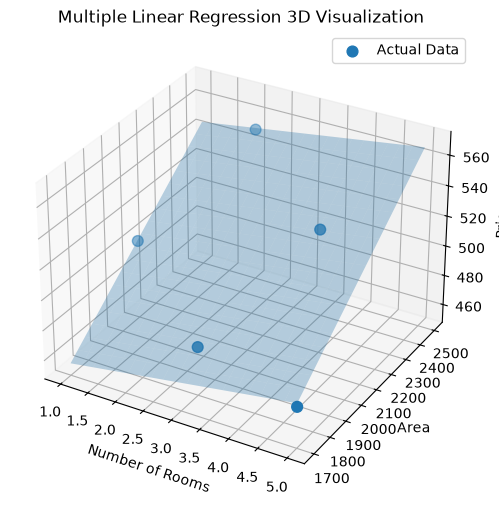

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D 그래프 생성
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# 실제 데이터 산점도
# X[:, 0] : 방 개수
# X[:, 1] : 면적
# y       : 실제 집 가격
ax.scatter(X[:, 0], X[:, 1], y, label="Actual Data", s=60)

# 회귀 평면을 그리기 위한 격자 데이터 생성
room_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
area_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)

room_grid, area_grid = np.meshgrid(room_range, area_range)

# 격자 데이터를 모델 입력 형태로 변환
grid_data = np.c_[room_grid.ravel(), area_grid.ravel()]

# 회귀 모델을 이용해 격자 위치의 예측 가격 계산
price_pred_grid = model.predict(grid_data)

# 예측 결과를 회귀 평면 형태로 변환
price_pred_grid = price_pred_grid.reshape(room_grid.shape)

# 회귀 평면 시각화
ax.plot_surface(room_grid, area_grid, price_pred_grid, alpha=0.3)

# 축 라벨 설정
ax.set_xlabel("Number of Rooms")
ax.set_ylabel("Area")
ax.set_zlabel("Price")

# 그래프 제목
ax.set_title("Multiple Linear Regression 3D Visualization")

# 범례 표시
ax.legend()

# 그래프 출력
plt.show()

c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\playdata2\ML\ml_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canva

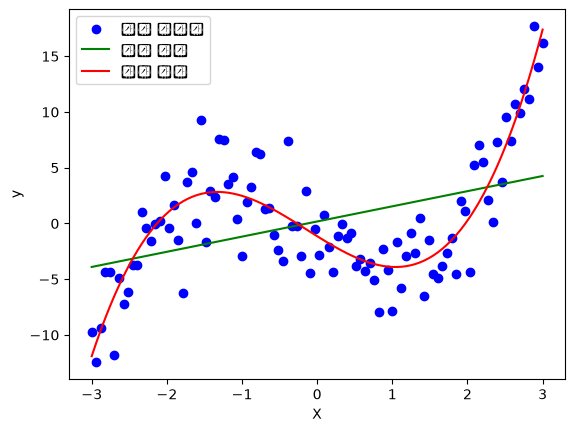

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 데이터 생성
np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = X**3 - 4 * X + np.random.randn(100, 1) * 3

# 1. 일반 선형 회귀
linear_model = LinearRegression()
linear_model.fit(X, y)
y_linear_pred = linear_model.predict(X)

# 2. 다항 특성 변환
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

# 3. 다항 회귀 모델 학습
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# 4. 결과 시각화
plt.scatter(X, y, color="blue", label="실제 데이터")
plt.plot(X, y_linear_pred, color="green", label="선형 회귀")
plt.plot(X, y_poly_pred, color="red", label="다항 회귀")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

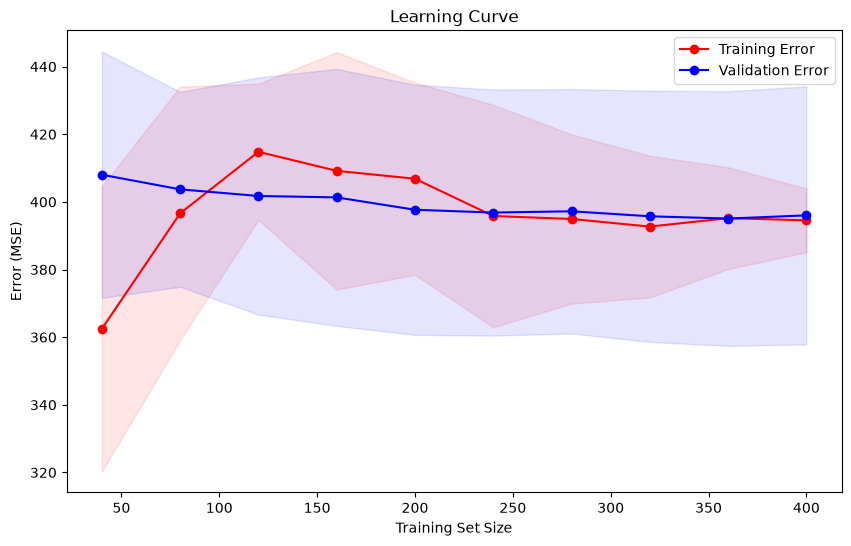

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

# 1. 데이터 생성
X, y = make_regression(
    n_samples=500,
    n_features=1,
    noise=20,
    random_state=42
)

# 2. 학습 곡선 계산
train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    shuffle=True,
    random_state=42
)

# 3. 평균과 표준편차 계산
# neg_mean_squared_error는 음수로 반환되므로 -를 붙여 양수 MSE로 변환
train_mean = -train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = -val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

# 4. 학습 곡선 시각화
plt.figure(figsize=(10, 6))

# 학습 오차
plt.plot(
    train_sizes,
    train_mean,
    "o-",
    label="Training Error",
    color="red"
)
# 검증 오차
plt.plot(
    train_sizes,
    val_mean,
    "o-",
    label="Validation Error",
    color="blue"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1,
    color="red"
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1,
    color="blue"
)

plt.xlabel("Training Set Size")
plt.ylabel("Error (MSE)")
plt.title("Learning Curve")
plt.legend()
plt.show()